# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import random
import sys
from pathlib import Path

import networkx as nx
import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.12.0+cpu
CUDA available: False


In [10]:
RANDOM_SEED = 7
DATASET_SIZE = 1024
CYCLE_LENGTH = (3,8)
PATH_LENGTH = (3,6)
NUM_RAYS = (2,4)
RAY_LENGTH = 2
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 2
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
EMBEDDING_DIM = 64
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [11]:
import random
import networkx as nx


def make_alphabet(size, kind="int", offset=0):
    if size <= 0:
        raise ValueError("Alphabet size must be >= 1.")

    if kind == "int":
        return list(range(offset, offset + size))

    if kind == "letter":
        if offset + size > 26:
            raise ValueError("Letter alphabet supports at most 26 symbols across all components.")
        return [chr(ord("A") + i) for i in range(offset, offset + size)]

    raise ValueError("kind must be 'int' or 'letter'.")


def make_component_alphabets(size, kind="int", component_specific_alphabets=True):
    components = ("cycle", "path", "star")
    if not component_specific_alphabets:
        shared_alphabet = make_alphabet(size, kind)
        return {component: shared_alphabet for component in components}
    return {
        component: make_alphabet(size, kind, offset=component_index * size)
        for component_index, component in enumerate(components)
    }


def generate_cycle_path_star_graph(
    cycle_length,
    path_length,
    num_rays,
    ray_length,
    node_alphabet_size=1,
    edge_alphabet_size=1,
    node_alphabet_kind="int",
    edge_alphabet_kind="int",
    component_specific_alphabets=True,
    seed=None,
):
    """
    Generate one connected NetworkX graph composed of:

        cycle -> connector path -> star with path-like rays

    When component_specific_alphabets=True, cycle, path, and star labels use
    non-overlapping node and edge alphabet blocks of the requested sizes.

    Degenerate cases:
    - cycle_length = 0 creates a single anchor node.
    - path_length = 0 makes the star hub coincide with the cycle anchor.
    - num_rays = 0 creates no rays.
    - ray_length = 0 makes each ray a single edge from hub to leaf.
    """

    if cycle_length < 0 or path_length < 0 or num_rays < 0 or ray_length < 0:
        raise ValueError("Structural parameters must be non-negative.")

    rng = random.Random(seed)

    node_labels_by_component = make_component_alphabets(
        node_alphabet_size,
        node_alphabet_kind,
        component_specific_alphabets=component_specific_alphabets,
    )
    edge_labels_by_component = make_component_alphabets(
        edge_alphabet_size,
        edge_alphabet_kind,
        component_specific_alphabets=component_specific_alphabets,
    )

    G = nx.Graph()
    next_node = 0

    def assign_node_label(node, component):
        G.nodes[node]["label"] = rng.choice(node_labels_by_component[component])
        G.nodes[node]["label_component"] = component

    def add_node(role, component):
        nonlocal next_node
        node = next_node
        next_node += 1
        G.add_node(node, role=role)
        assign_node_label(node, component)
        return node

    def add_edge(u, v, role, component):
        G.add_edge(
            u,
            v,
            label=rng.choice(edge_labels_by_component[component]),
            role=role,
            label_component=component,
        )

    # 1. Cycle component
    if cycle_length == 0:
        cycle_nodes = [add_node("cycle_anchor", "cycle")]
    elif cycle_length < 3:
        raise ValueError("cycle_length must be 0 or >= 3 for a simple cycle.")
    else:
        cycle_nodes = [add_node("cycle", "cycle") for _ in range(cycle_length)]
        for i in range(cycle_length):
            add_edge(cycle_nodes[i], cycle_nodes[(i + 1) % cycle_length], "cycle", "cycle")

    anchor = rng.choice(cycle_nodes)
    G.nodes[anchor]["role"] = "cycle_anchor"

    # 2. Connector path
    current = anchor

    for _ in range(path_length):
        new_node = add_node("path", "path")
        add_edge(current, new_node, "path", "path")
        current = new_node

    hub = current
    G.nodes[hub]["role"] = "star_hub"
    assign_node_label(hub, "star")

    # 3. Star rays
    for ray_id in range(num_rays):
        current = hub

        if ray_length == 0:
            leaf = add_node(f"ray_{ray_id}_leaf", "star")
            add_edge(hub, leaf, "star_ray", "star")
        else:
            for step in range(ray_length):
                role = f"ray_{ray_id}_node"
                if step == ray_length - 1:
                    role = f"ray_{ray_id}_leaf"

                new_node = add_node(role, "star")
                add_edge(current, new_node, "star_ray", "star")
                current = new_node

    G.graph["metadata"] = {
        "cycle_length": cycle_length,
        "path_length": path_length,
        "num_rays": num_rays,
        "ray_length": ray_length,
        "node_alphabet_size": node_alphabet_size,
        "edge_alphabet_size": edge_alphabet_size,
        "component_specific_alphabets": component_specific_alphabets,
        "node_alphabets_by_component": node_labels_by_component,
        "edge_alphabets_by_component": edge_labels_by_component,
    }

    assert nx.is_connected(G)

    return G


def _sample_int_parameter(value, rng, name, *, minimum=None, valid_values=None):
    """Resolve either a fixed integer or an inclusive integer range."""
    if isinstance(value, tuple):
        if len(value) != 2:
            raise ValueError(f"{name} range must be a 2-tuple: (min, max).")
        low, high = value
        if not isinstance(low, int) or not isinstance(high, int):
            raise TypeError(f"{name} range bounds must be integers.")
        if high < low:
            raise ValueError(f"{name} range max must be >= min.")
        candidates = list(range(low, high + 1))
        if minimum is not None:
            candidates = [candidate for candidate in candidates if candidate >= minimum]
        if valid_values is not None:
            candidates = [candidate for candidate in candidates if valid_values(candidate)]
        if not candidates:
            raise ValueError(f"{name} range {value!r} contains no valid values.")
        return rng.choice(candidates)

    if not isinstance(value, int):
        raise TypeError(f"{name} must be an integer or a 2-tuple integer range.")
    if minimum is not None and value < minimum:
        raise ValueError(f"{name} must be >= {minimum}.")
    if valid_values is not None and not valid_values(value):
        raise ValueError(f"{name} has invalid value {value!r}.")
    return value


def generate_dataset(
    num_graphs,
    cycle_length,
    path_length,
    num_rays,
    ray_length,
    node_alphabet_size=1,
    edge_alphabet_size=1,
    node_alphabet_kind="int",
    edge_alphabet_kind="int",
    component_specific_alphabets=True,
    seed=None,
):
    """
    Generate a list of NetworkX graphs.

    Integer-valued graph parameters can be fixed integers or inclusive
    2-tuples. For example, ``path_length=(1, 4)`` samples a path length
    uniformly from 1, 2, 3, and 4 independently for each generated graph.
    By default, cycle, path, and star components use non-overlapping node
    and edge alphabet blocks.
    """

    if not isinstance(num_graphs, int) or num_graphs < 0:
        raise ValueError("num_graphs must be a non-negative integer.")

    rng = random.Random(seed)
    graphs = []

    for _ in range(num_graphs):
        sampled_cycle_length = _sample_int_parameter(
            cycle_length,
            rng,
            "cycle_length",
            minimum=0,
            valid_values=lambda candidate: candidate == 0 or candidate >= 3,
        )
        sampled_path_length = _sample_int_parameter(path_length, rng, "path_length", minimum=0)
        sampled_num_rays = _sample_int_parameter(num_rays, rng, "num_rays", minimum=0)
        sampled_ray_length = _sample_int_parameter(ray_length, rng, "ray_length", minimum=0)
        sampled_node_alphabet_size = _sample_int_parameter(
            node_alphabet_size,
            rng,
            "node_alphabet_size",
            minimum=1,
        )
        sampled_edge_alphabet_size = _sample_int_parameter(
            edge_alphabet_size,
            rng,
            "edge_alphabet_size",
            minimum=1,
        )

        graphs.append(
            generate_cycle_path_star_graph(
                cycle_length=sampled_cycle_length,
                path_length=sampled_path_length,
                num_rays=sampled_num_rays,
                ray_length=sampled_ray_length,
                node_alphabet_size=sampled_node_alphabet_size,
                edge_alphabet_size=sampled_edge_alphabet_size,
                node_alphabet_kind=node_alphabet_kind,
                edge_alphabet_kind=edge_alphabet_kind,
                component_specific_alphabets=component_specific_alphabets,
                seed=rng.randint(0, 2**32 - 1),
            )
        )

    return graphs


Loaded 1024 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 10/16/22
Edge count min/median/max = 10/16/22
Metadata: {'cycle_length': 5, 'path_length': 4, 'num_rays': 3, 'ray_length': 2, 'node_alphabet_size': 3, 'edge_alphabet_size': 2, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0, 1], 'path': [2, 3], 'star': [4, 5]}}


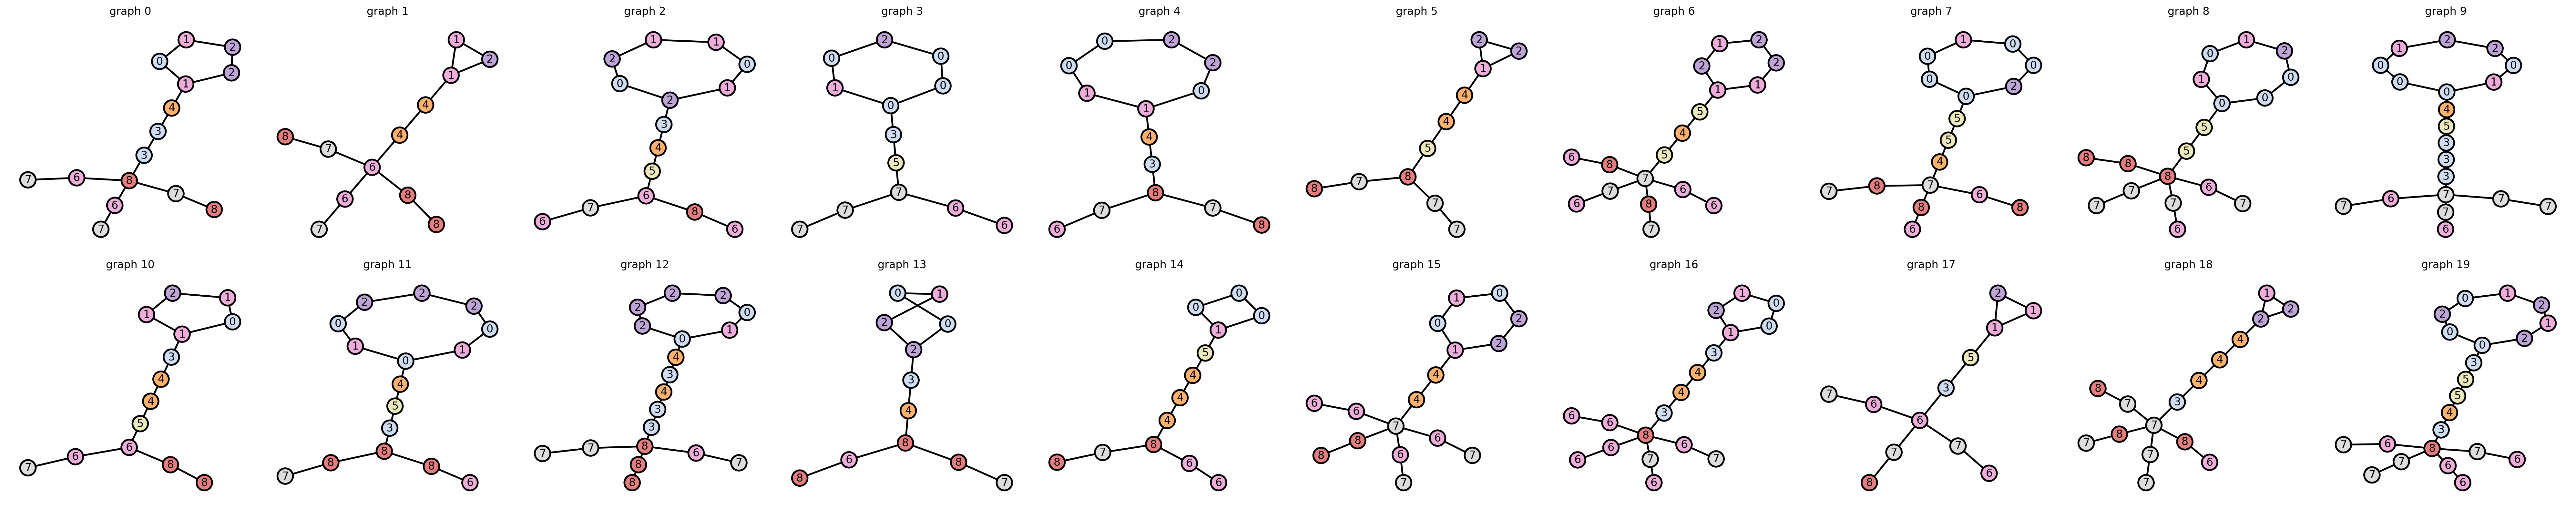

Configured graph generator model_name=artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [14]:
graphs = generate_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_networkx_graphs(graphs[:20], n_cols=10, titles=[f'graph {idx}' for idx in range(20)])

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=2,
    transformer_attention_head_count=4,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=2,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_networkx_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs


Fit target model_name=artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 1024 graphs
Fitting feasibility estimator on 1024 graphs
Finished fitting feasibility estimator in 0m 23.6s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 6 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 97926 pairs (50.00%) from 195852 total pairs (pos=65328, neg=130524, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=32664, neg=65262, positive_rat

/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


epoch 1: finished validation in 3.48s
epoch 1: starting validation
epoch 1: finished validation in 3.21s
epoch 1: saving generator snapshot
epoch 1: finished generator snapshot in 0.63s
epoch 2: starting validation
epoch 2: finished validation in 3.35s
epoch 2: saving generator snapshot
epoch 2: finished generator snapshot in 1.80s
epoch 3: starting validation
epoch 3: finished validation in 3.11s
epoch 3: saving generator snapshot
epoch 3: finished generator snapshot in 1.74s
epoch 4: starting validation
epoch 4: finished validation in 2.97s
epoch 4: saving generator snapshot
epoch 4: finished generator snapshot in 1.78s
epoch 5: starting validation
epoch 5: finished validation in 3.27s
epoch 5: saving generator snapshot
epoch 5: finished generator snapshot in 1.73s
epoch 6: starting validation
epoch 6: finished validation in 3.29s
epoch 6: saving generator snapshot
epoch 6: finished generator snapshot in 1.85s
epoch 7: starting validation
epoch 7: finished validation in 3.25s
epoch 7

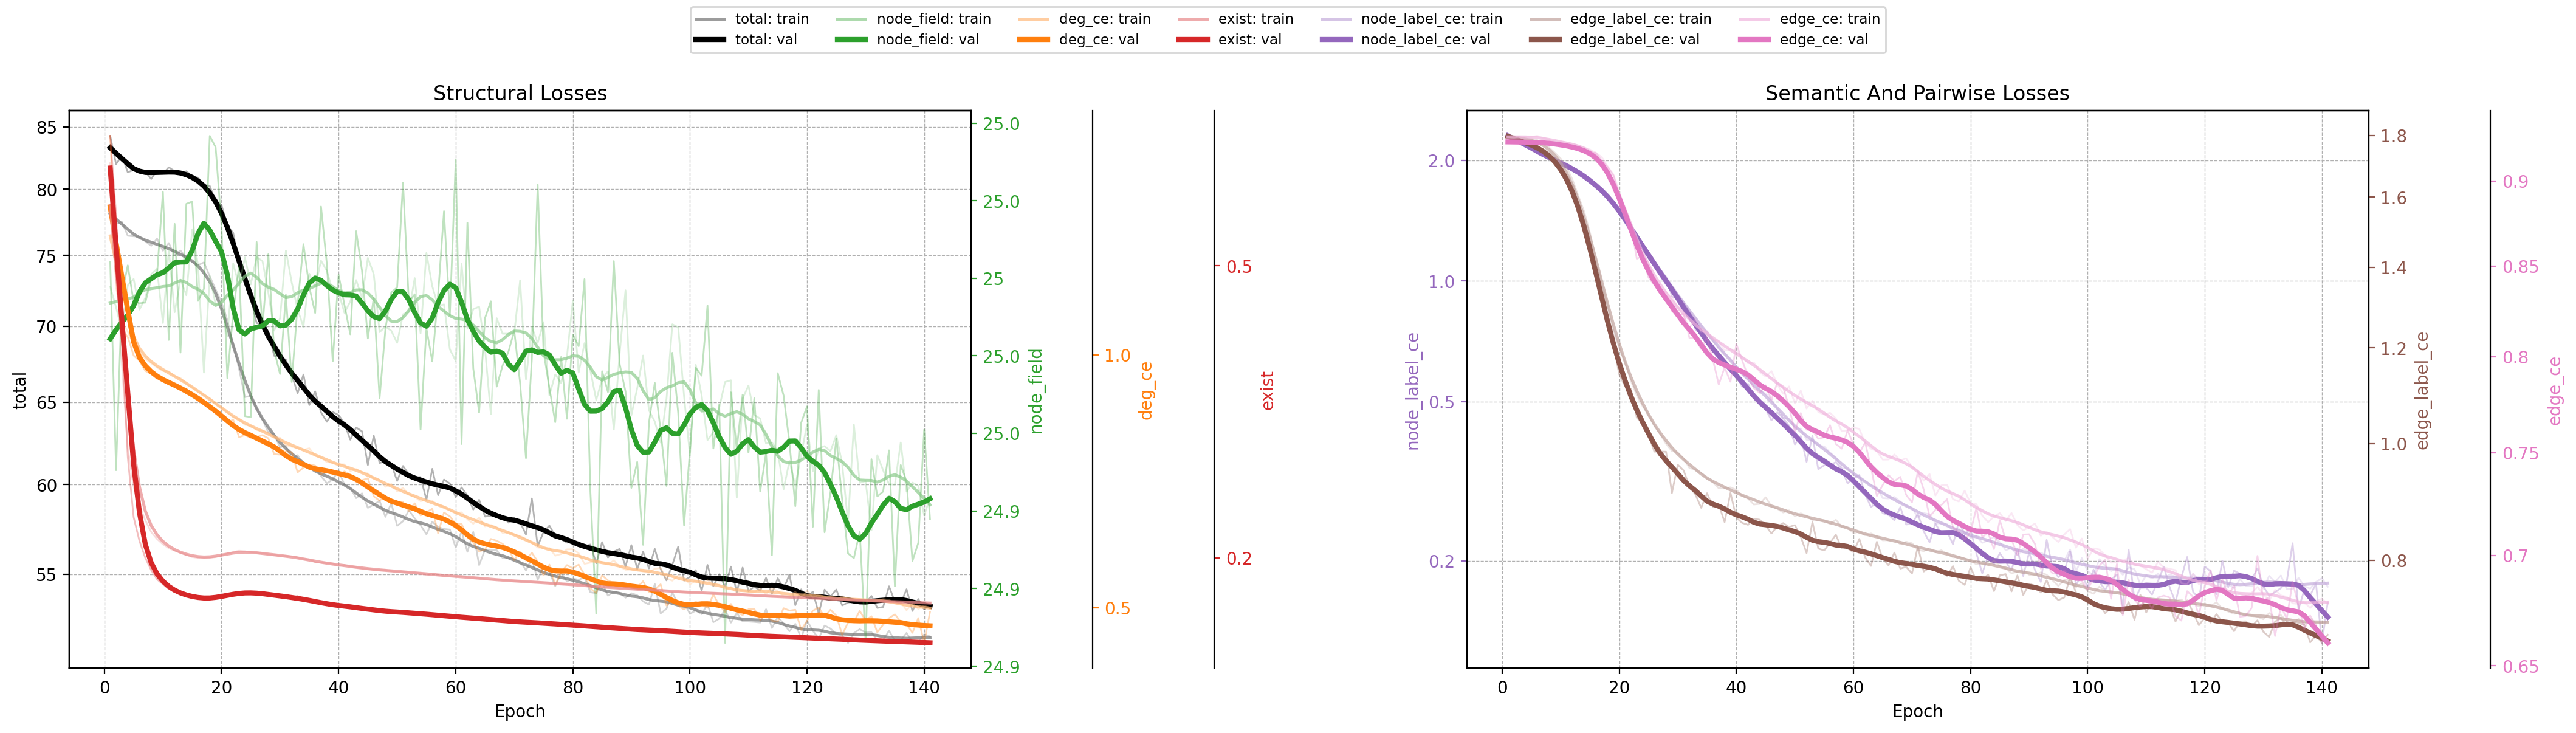

training_graph_conditioning_ = 1024
is_fitted_ = True


In [15]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [16]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


,name,modified,size_mb
0,artificial-cycle-path-star-n1024-c-3-8-p-3-6-r...,2026-05-20 15:26,20.2
1,artificial-cycle-path-star-n512-c6-p3-r4x2-d64...,2026-05-20 12:02,12.1
2,zinc20-nonstreaming-d64-s0-99-b128-e350.pkl,2026-05-12 15:39,1087.7
3,zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl,2026-04-02 14:27,36.1
4,zinc15-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 14:27,176.1
5,zinc15-streaming-d64-s0-5-w256-b8-e256.pkl,2026-04-02 04:54,8.1
6,artificial-d32-n86-size8.pkl,2026-03-24 19:40,4.4


Loaded graph generator: artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl
/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl


In [ ]:
raw_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=False,
)
plot_networkx_graphs(raw_samples, n_cols=7, titles=[f'raw {idx}' for idx in range(len(raw_samples))])


Sampling 7 graphs


In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=7,
        apply_feasibility_filtering=True,
    )
    plot_networkx_graphs(filtered_samples, n_cols=7, titles=[f'filtered {idx}' for idx in range(len(filtered_samples))])
